# 한글 깨짐 방지 폰트 설정

In [27]:
%pip install koreanize-matplotlib
import koreanize_matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. 데이터 불러오기
df = pd.read_csv('제목행번역.csv')
df.head()

,아이돌이름,아이돌검색수,방송일자,채널명,프로그램명,방송회차,프로그램장르명,고정출연자명,출연자명,남성시청률,여성시청률
0,비투비,524758,20200907,국방TV,쇼챔피언,14,음악쇼,"문빈,윤산하,강민","소녀시대-태티서,에이핑크,비투비,가비엔제이,디셈버,포커즈,EXO-M,리듬파워,류키,...",0.00781,0.00317
1,비투비,524758,20200912,국방TV,쇼챔피언,14,음악쇼,"문빈,윤산하,강민","소녀시대-태티서,에이핑크,비투비,가비엔제이,디셈버,포커즈,EXO-M,리듬파워,류키,...",0.01345,0.02648
2,비투비,524758,20200921,국방TV,쇼챔피언,16,음악쇼,"문빈,윤산하,강민","FT아일랜드,CNBLUE,샤이니,소녀시대-태티서,인피니트,비투비,B.A.P,포미닛,...",0.20508,0.04446
3,비투비,524758,20200926,국방TV,쇼챔피언,16,음악쇼,"문빈,윤산하,강민","FT아일랜드,CNBLUE,샤이니,소녀시대-태티서,인피니트,비투비,B.A.P,포미닛,...",0.00305,0.00523
4,샤이니,292880,20200921,국방TV,쇼챔피언,16,음악쇼,"문빈,윤산하,강민","FT아일랜드,CNBLUE,샤이니,소녀시대-태티서,인피니트,비투비,B.A.P,포미닛,...",0.20508,0.04446


In [29]:
# 2. 상관계수 구하기
corr = df['남성시청률'].corr(df['여성시청률'])
print(f'남성시청률과 여성시청률의 상관계수: {corr:.4f}')

남성시청률과 여성시청률의 상관계수: 0.9822


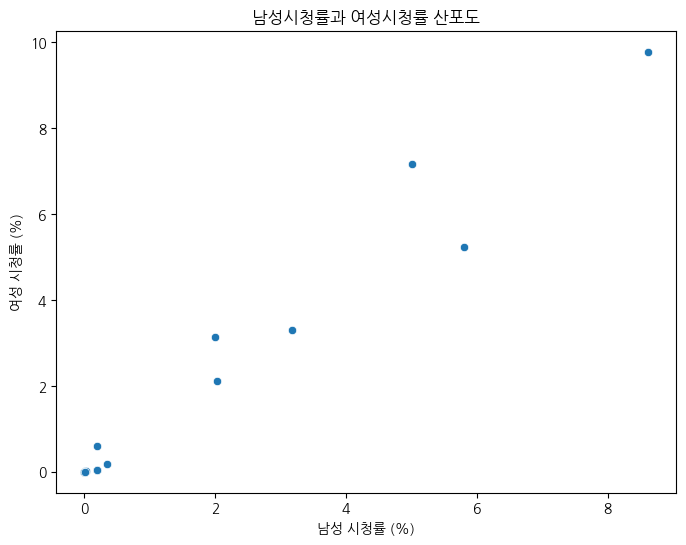

In [30]:
# 3. 산포도 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(x='남성시청률', y='여성시청률', data=df)
plt.title('남성시청률과 여성시청률 산포도')
plt.xlabel('남성 시청률 (%)')
plt.ylabel('여성 시청률 (%)')

# 그래프 이미지 저장
plt.savefig('산포도.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# 4. 선형회귀 모델 학습
X = df[['남성시청률']]
y = df['여성시청률']

model = LinearRegression()
model.fit(X, y)

target_male_rt = 10.0
pred_female_rt = model.predict([[target_male_rt]])[0]
print(f'남성 시청률이 {target_male_rt}%일 때, 예상되는 여성 시청률은 {pred_female_rt:.4f}% 입니다.')

남성 시청률이 10.0%일 때, 예상되는 여성 시청률은 11.3242% 입니다.


/home/an0jin/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


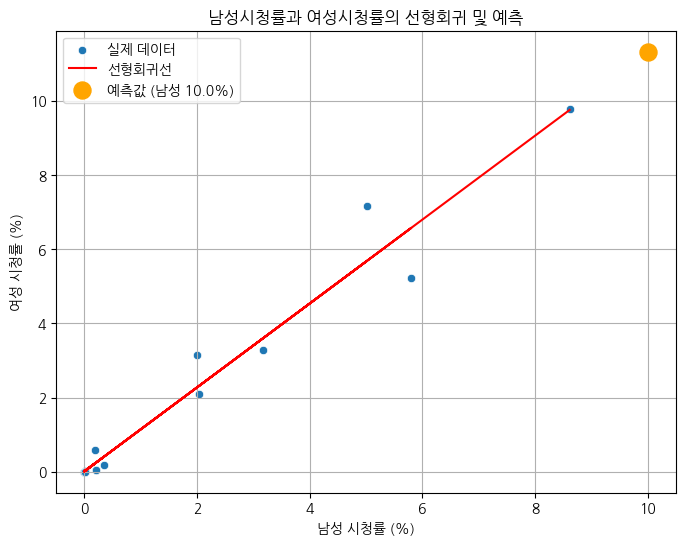

In [32]:
# 5. 선형회귀 시각화 (남성 시청률이 10%일 때의 결과 포함)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='남성시청률', y='여성시청률', data=df, label='실제 데이터')
plt.plot(X, model.predict(X), color='red', label='선형회귀선')
plt.scatter([target_male_rt], [pred_female_rt], color='orange', s=150, zorder=5, label=f'예측값 (남성 {target_male_rt}%)')
plt.title('남성시청률과 여성시청률의 선형회귀 및 예측')
plt.xlabel('남성 시청률 (%)')
plt.ylabel('여성 시청률 (%)')
plt.legend()
plt.grid(True)

# 그래프 이미지 저장
plt.savefig('선형회귀_예측결과.png', dpi=300, bbox_inches='tight')
plt.show()

# 다항회귀 (Polynomial Regression) 분석 추가

In [33]:
# 6. 다항회귀(2차) 모델 학습
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# 남성 시청률이 10%일 때 다항회귀 기반 예측
X_target_poly = poly_features.transform([[target_male_rt]])
pred_poly_female_rt = poly_model.predict(X_target_poly)[0]
print(f'[다항회귀 모델] 남성 시청률이 {target_male_rt}%일 때, 예상되는 여성 시청률은 {pred_poly_female_rt:.4f}% 입니다.')

[다항회귀 모델] 남성 시청률이 10.0%일 때, 예상되는 여성 시청률은 11.7782% 입니다.


/home/an0jin/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


/tmp/ipykernel_11974/2200525047.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  X_plot = np.linspace(X.min()[0], X.max()[0], 100).reshape(-1, 1)
/home/an0jin/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


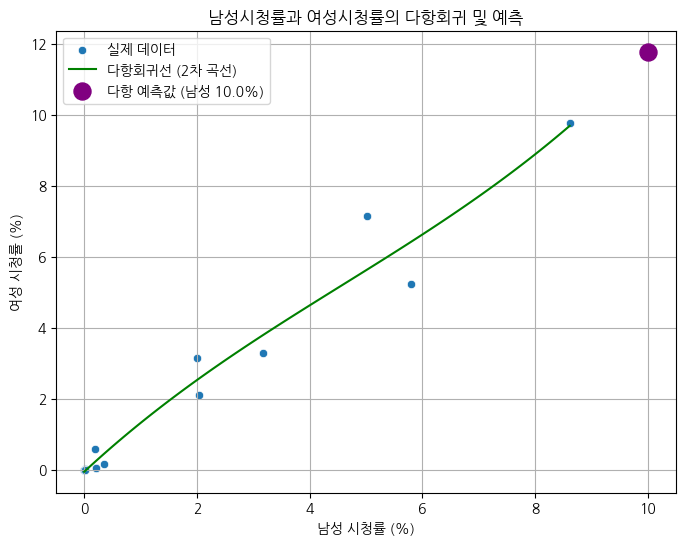

In [34]:
# 7. 다항회귀 곡선 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(x='남성시청률', y='여성시청률', data=df, label='실제 데이터')

# 매끄러운 다항회귀 곡선을 그리기 위해 데이터 생성
X_plot = np.linspace(X.min()[0], X.max()[0], 100).reshape(-1, 1)
X_plot_poly = poly_features.transform(X_plot)
y_plot_poly = poly_model.predict(X_plot_poly)

plt.plot(X_plot, y_plot_poly, color='green', label='다항회귀선 (2차 곡선)')
plt.scatter([target_male_rt], [pred_poly_female_rt], color='purple', s=150, zorder=5, label=f'다항 예측값 (남성 {target_male_rt}%)')

plt.title('남성시청률과 여성시청률의 다항회귀 및 예측')
plt.xlabel('남성 시청률 (%)')
plt.ylabel('여성 시청률 (%)')
plt.legend()
plt.grid(True)

# 그래프 이미지 저장
plt.savefig('다항회귀_예측결과.png', dpi=300, bbox_inches='tight')
plt.show()